In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),  
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor()
])

In [4]:
data_dir = "dataset"

train_data = datasets.ImageFolder(f"{data_dir}/train", transform=train_transform)
val_data = datasets.ImageFolder(f"{data_dir}/val", transform=val_transform)
test_data = datasets.ImageFolder(f"{data_dir}/test", transform=val_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

class_names = train_data.classes
print("Classes:", class_names)

Classes: ['abnormal', 'myocardial', 'normal', 'post_mi']


In [5]:
model = models.resnet18(pretrained=True)

# Modify last layer for 4 classes
model.fc = nn.Linear(model.fc.in_features, len(class_names))

model = model.to(device)

c:\Users\hasha\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\hasha\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [7]:
epochs = 10

train_acc_list = []
val_acc_list = []

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")

    # TRAIN
    model.train()
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_acc = train_correct / train_total
    train_acc_list.append(train_acc)

    # VALIDATION
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    val_acc_list.append(val_acc)

    print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")


Epoch 1/10
Train Acc: 0.3357 | Val Acc: 0.3125

Epoch 2/10
Train Acc: 0.5643 | Val Acc: 0.2812

Epoch 3/10
Train Acc: 0.6786 | Val Acc: 0.2188

Epoch 4/10
Train Acc: 0.7643 | Val Acc: 0.5312

Epoch 5/10
Train Acc: 0.8071 | Val Acc: 0.6250

Epoch 6/10
Train Acc: 0.8429 | Val Acc: 0.6250

Epoch 7/10
Train Acc: 0.7857 | Val Acc: 0.7500

Epoch 8/10
Train Acc: 0.8571 | Val Acc: 0.7812

Epoch 9/10
Train Acc: 0.8929 | Val Acc: 0.7188

Epoch 10/10
Train Acc: 0.8429 | Val Acc: 0.7188


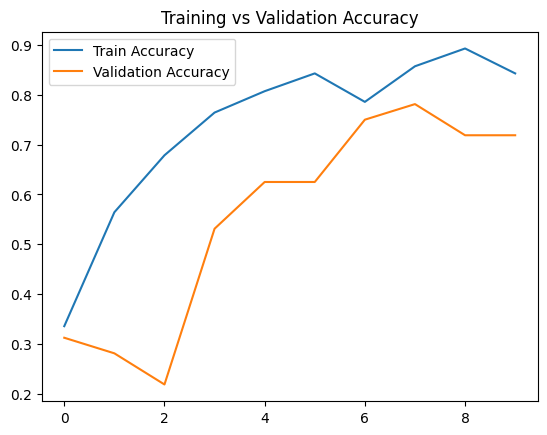

In [8]:
plt.plot(train_acc_list, label="Train Accuracy")
plt.plot(val_acc_list, label="Validation Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

In [9]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = correct / total
print("Test Accuracy:", test_acc)

Test Accuracy: 0.8214285714285714


In [10]:
torch.save(model.state_dict(), "ecg_model.pth")